# Bays (2014) Figure 5 — Baseline Activity Effects

Panels: **a** gain vs baseline, **b** width vs baseline, **c** error distributions, **d** SNR vs baseline.

Demonstrates that increasing baseline activity shifts ML gain upward but leaves SNR (and thus error distributions) approximately invariant.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import time
from scipy.special import logsumexp

from core.encoder.gaussian_process import (
    generate_neuron_population, periodic_rbf_kernel, sample_gp_function,
)
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


In [2]:
# Single-location full Poisson ML decoder + circular stats
# (Not in core — core has the multi-item factorised decoder)

def compute_log_likelihood(counts, g, T_d):
    log_g = np.log(np.maximum(g, 1e-30))
    return counts @ log_g - T_d * np.sum(g, axis=0)

def compute_circular_error(theta_true, theta_hat):
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

def circular_variance(errors):
    return 1.0 - np.abs(np.mean(np.exp(1j * errors)))

def circular_kurtosis(errors):
    V = circular_variance(errors)
    rho2 = np.abs(np.mean(np.exp(2j * errors)))
    kappa2 = 1.0 - rho2
    return kappa2 / max(V**2, 1e-15) if V > 1e-10 else 0.0

def compute_deviation_from_normal(errors, n_bins=50):
    from scipy.stats import vonmises
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    V = circular_variance(errors)
    kappa_fit = max(0.01, 1.0 / V - 1) if V > 0.01 else 100.0
    vm_pdf = vonmises.pdf(centers, kappa_fit)
    return {'bin_centers': centers, 'empirical': emp, 'normal_fit': vm_pdf,
            'deviation': emp - vm_pdf}

# Multi-item factorised decoder (Eqs. 23-26)
def compute_spike_weighted_log_tuning(counts, f_list):
    return [counts @ f_k for f_k in f_list]

def compute_marginal_log_likelihood_efficient(L_list, cued_idx):
    ll = L_list[cued_idx].copy()
    for k in range(len(L_list)):
        if k != cued_idx:
            ll = ll + logsumexp(L_list[k])
    return ll

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================
M = 100; N_THETA = 64; T_D = 0.1; SIGMA_SQ = 1e-6
LAMBDA_REF = 0.5; GAMMA_REF = 100.0
SET_SIZES = [1, 2, 4, 8]
BASELINE_FRACS = [0.0, 0.05, 0.20, 0.50, 0.80]
N_TRIALS_FIT = 2000; N_TRIALS_FINAL = 5000
SEED = 42; N_BINS = 50

## Population generation with baseline

In [4]:
def gen_pop_baseline(M, n_theta, lengthscale, baseline_frac, seed):
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    K = periodic_rbf_kernel(thetas, lengthscale)
    f = np.zeros((M, n_theta))
    for i in range(M):
        f[i] = sample_gp_function(K, rng)
    g_raw = np.exp(f)
    if baseline_frac < 1e-10:
        b0 = 0.0
    else:
        b0 = baseline_frac * np.mean(np.max(g_raw, axis=1)) / (1.0 - baseline_frac)
    return thetas, g_raw + b0, g_raw

def run_trials_baseline(g, thetas, gamma, T_d, sigma_sq, n_trials, rng):
    M, n_theta = g.shape
    errors = np.empty(n_trials)
    for t in range(n_trials):
        idx = rng.randint(n_theta)
        rates = dn_pointwise(g[:, idx], gamma, sigma_sq)
        counts = generate_spikes(rates, T_d, rng)
        ll = compute_log_likelihood(counts, g, T_d)
        errors[t] = compute_circular_error(thetas[idx], thetas[np.argmax(ll)])
    return errors

def compute_snr(g, gamma, T_d, sigma_sq, N_items=1):
    M, n_theta = g.shape
    denom = sigma_sq + N_items * np.mean(g, axis=0)
    rates = gamma * g / denom[np.newaxis, :]
    return np.mean(T_d * np.var(rates, axis=1) / np.maximum(np.mean(rates, axis=1), 1e-15))

## Phase 1: Reference + Phase 2: Sweep baselines

In [5]:
t0 = time.time()

# Phase 1: reference (zero baseline)
thetas_ref, g_ref, _ = gen_pop_baseline(M, N_THETA, LAMBDA_REF, 0.0, SEED)
target_vars = {}
for N in SET_SIZES:
    rng = np.random.RandomState(SEED + N)
    errs = run_trials_baseline(g_ref, thetas_ref, GAMMA_REF/N, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
    target_vars[N] = circular_variance(errs)
    print(f"  Reference N={N}: var={target_vars[N]:.4f}")

# Phase 2: at each baseline, find gamma that matches reference variance
results = {}
for bf in BASELINE_FRACS:
    thetas_b, g_b, g_raw = gen_pop_baseline(M, N_THETA, LAMBDA_REF, bf, SEED)
    if bf < 1e-10:
        best_gamma = GAMMA_REF
    else:
        gamma_grid = np.logspace(np.log10(10), np.log10(1e5), 15)
        best_cost, best_gamma = np.inf, GAMMA_REF
        for gam in gamma_grid:
            cost = 0
            for N in SET_SIZES:
                rng = np.random.RandomState(SEED + N + int(bf*1000))
                errs = run_trials_baseline(g_b, thetas_b, gam/N, T_D, SIGMA_SQ, 500, rng)
                v = circular_variance(errs)
                if v > 1e-10 and target_vars[N] > 1e-10:
                    cost += (np.log(v) - np.log(target_vars[N]))**2
            if cost < best_cost:
                best_cost, best_gamma = cost, gam

    # Full sim + SNR
    snr = compute_snr(g_b, best_gamma, T_D, SIGMA_SQ)
    dists = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(SEED + N + int(bf*10000))
        errs = run_trials_baseline(g_b, thetas_b, best_gamma/N, T_D, SIGMA_SQ, N_TRIALS_FINAL, rng)
        dists[N] = compute_deviation_from_normal(errs, N_BINS)

    results[bf] = {'gamma': best_gamma, 'lambda': LAMBDA_REF, 'snr': snr, 'dists': dists}
    print(f"  baseline={bf*100:.0f}%: gamma={best_gamma:.1f} snr={snr:.3f}")

bins = results[BASELINE_FRACS[0]]['dists'][SET_SIZES[0]]['bin_centers']
print(f"Done in {time.time()-t0:.1f}s")

  Reference N=1: var=0.0074
  Reference N=2: var=0.0067
  Reference N=4: var=0.0068
  Reference N=8: var=0.0068
  baseline=0%: gamma=100.0 snr=8.982
  baseline=5%: gamma=26827.0 snr=1750.129
  baseline=20%: gamma=100000.0 snr=2805.623
  baseline=50%: gamma=72.0 snr=0.402
  baseline=80%: gamma=72.0 snr=0.040
Done in 23.8s


## Plot: 2x2 panels

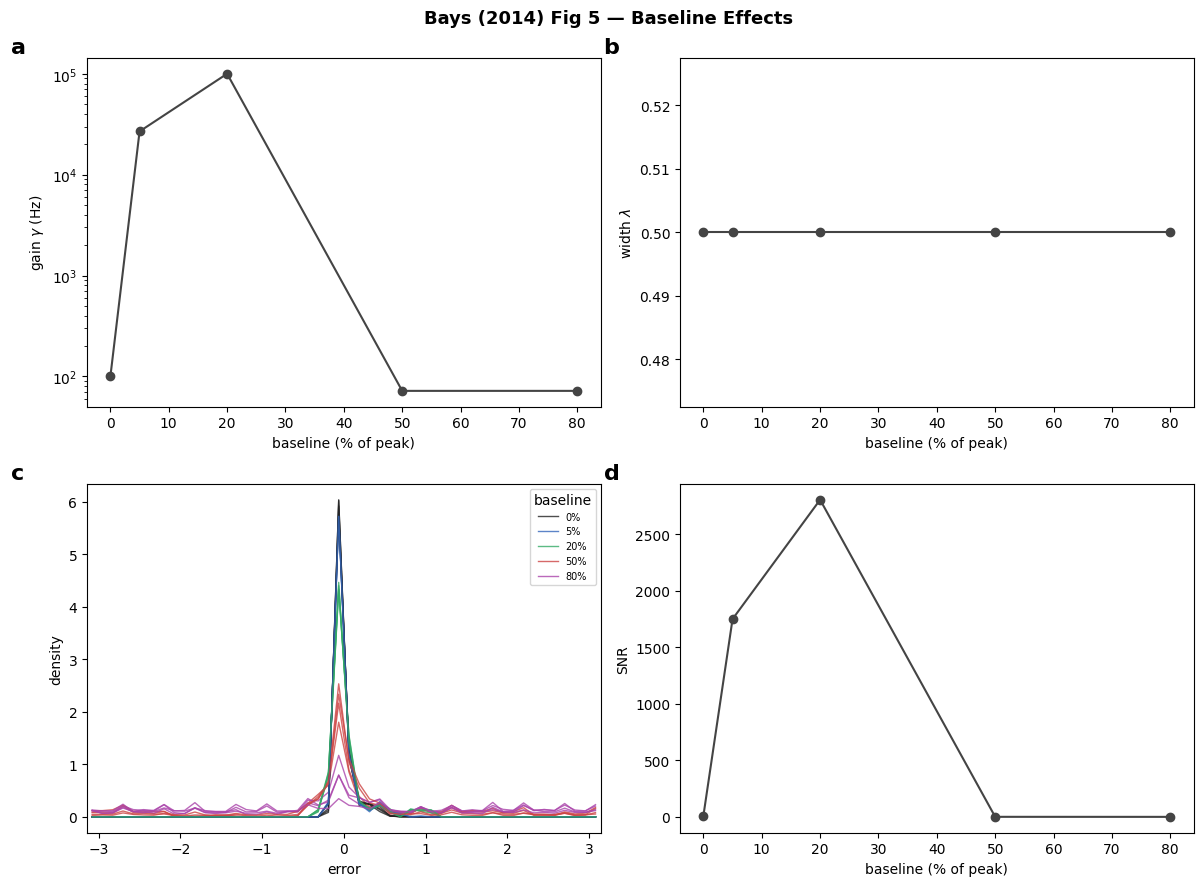

In [6]:
GREY = '#444444'
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
x_pct = [bf*100 for bf in BASELINE_FRACS]

axes[0,0].semilogy(x_pct, [results[bf]['gamma'] for bf in BASELINE_FRACS], 'o-', color=GREY, lw=1.5)
axes[0,0].set_xlabel('baseline (% of peak)'); axes[0,0].set_ylabel(r'gain $\gamma$ (Hz)')
axes[0,0].text(-0.15,1.06,r'$\mathbf{a}$',transform=axes[0,0].transAxes,fontsize=16,fontweight='bold',va='top')

axes[0,1].plot(x_pct, [results[bf]['lambda'] for bf in BASELINE_FRACS], 'o-', color=GREY, lw=1.5)
axes[0,1].set_xlabel('baseline (% of peak)'); axes[0,1].set_ylabel(r'width $\lambda$')
axes[0,1].text(-0.15,1.06,r'$\mathbf{b}$',transform=axes[0,1].transAxes,fontsize=16,fontweight='bold',va='top')

colors_c = ['#222222', '#3366BB', '#33AA66', '#CC4444', '#AA44AA']
for N in SET_SIZES:
    for bi, bf in enumerate(BASELINE_FRACS):
        c = colors_c[bi % len(colors_c)]
        label = f'{bf*100:.0f}%' if N==SET_SIZES[0] else None
        axes[1,0].plot(bins, results[bf]['dists'][N]['empirical'], color=c, lw=1, alpha=0.8, label=label)
axes[1,0].set_xlim(-np.pi, np.pi); axes[1,0].set_xlabel('error'); axes[1,0].set_ylabel('density')
axes[1,0].legend(fontsize=7, title='baseline')
axes[1,0].text(-0.15,1.06,r'$\mathbf{c}$',transform=axes[1,0].transAxes,fontsize=16,fontweight='bold',va='top')

axes[1,1].plot(x_pct, [results[bf]['snr'] for bf in BASELINE_FRACS], 'o-', color=GREY, lw=1.5)
axes[1,1].set_xlabel('baseline (% of peak)'); axes[1,1].set_ylabel('SNR')
axes[1,1].text(-0.15,1.06,r'$\mathbf{d}$',transform=axes[1,1].transAxes,fontsize=16,fontweight='bold',va='top')

fig.suptitle('Bays (2014) Fig 5 — Baseline Effects', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()